# Exploración de chunking — corpus Sistema Penal Acusatorio

Este notebook analiza **todos los Markdown** del corpus para decidir un chunking que respete su estructura.

Los documentos no son homogéneos: algunos son códigos organizados por artículos; otros son libros por capítulos, y otros reúnen criterios jurisprudenciales. Por ello se comparan unidades semánticas candidatas y se propone una regla por documento.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

current_dir = Path.cwd()
labs_folder = next(d for d in [current_dir, *current_dir.parents] if (d / 'shared').exists())
if str(labs_folder) not in sys.path:
    sys.path.insert(0, str(labs_folder))

CORPUS_PATH = labs_folder / 'ingestion' / 'out' / 'Sistema Penal Acusatorio'
print('Labs root:', labs_folder)
print('Corpus:', CORPUS_PATH)

Labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs
Corpus: /Users/savashito/Claude/Projects/AI_research/RAG/labs/ingestion/out/Sistema Penal Acusatorio


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# El chunking validado vive en shared.legal_chunking (probado en tests/). Este
# notebook ya NO lo redefine: sólo lo usa para el análisis, las gráficas y las guardas.
from shared.legal_chunking import (
    TARGET_WORDS, MAX_WORDS, MIN_WORDS, OVERLAP_WORDS, REMOVAL_REASONS,
    HEADING_RE, ARTICLE_RE, HEADING_PAGE_RE, ARTICLE_DENSITY_MIN, CATALOG_RECORD_RE,
    normalize_line, clean_document, words, article_density, document_strategy,
    semantic_units, merge_small_siblings, split_by_paragraphs, make_chunks,
)

paths = sorted(CORPUS_PATH.glob('*.md'))
assert paths, f'No encontré archivos Markdown en {CORPUS_PATH}'
print(f'Documentos encontrados: {len(paths)}')

Documentos encontrados: 24


## 1. Limpieza conservadora

Se quitan sólo líneas inequívocamente editoriales: paginación y encabezados institucionales repetidos. El contenido y los títulos se preservan; conviene revisar cualquier regla nueva sobre una muestra antes de incorporarla al pipeline de ingestión.

In [3]:
# Limpieza vía shared.legal_chunking (reglas + clean_document en la librería).
raw_documents = {path.name: path.read_text(encoding='utf-8') for path in paths}
cleaned = {name: clean_document(text) for name, text in raw_documents.items()}
documents = {name: result['clean_text'] for name, result in cleaned.items()}
cleaning_audit = pd.DataFrame([
    {'document': name, **result['removed_by_reason']}
    for name, result in cleaned.items()
]).reindex(columns=['document', *REMOVAL_REASONS], fill_value=0).fillna(0)
cleaning_audit = cleaning_audit.assign(
    raw_char_count=lambda df: df.document.map(lambda name: len(raw_documents[name])),
    clean_char_count=lambda df: df.document.map(lambda name: len(documents[name])),
    removed_char_count=lambda df: df.raw_char_count - df.clean_char_count,
    removed_line_count=lambda df: df[REMOVAL_REASONS].sum(axis=1),
)
print(f'Caracteres limpios: {sum(map(len, documents.values())):,}')

Caracteres limpios: 9,804,033


In [4]:
# Revisa el efecto de la limpieza: el catálogo y el índice no deben llegar al embedding.
cleaning_audit.sort_values('removed_line_count', ascending=False).head(10)

,document,catalog_record,contents_table,repeated_heading,heading_page_marker,editorial_watermark,page_number,institutional_header,raw_char_count,clean_char_count,removed_char_count,removed_line_count
8,Enseñanza judicial para la valoración de la pr...,0.0,23.0,27.0,4.0,1045.0,342.0,0.0,821885,686014,135871,1441.0
19,Los principios en el procedimiento penal acusa...,0.0,23.0,70.0,11.0,816.0,273.0,0.0,679620,565944,113676,1193.0
4,Desafíos en el Sistema Penal Acusatorio.md,0.0,22.0,44.0,2.0,625.0,279.0,1.0,818296,716905,101391,973.0
2,Código Penal Federal.md,0.0,0.0,170.0,0.0,0.0,353.0,354.0,872274,822723,49551,877.0
16,La prueba libre y lógica. Sistema penal acusat...,0.0,88.0,0.0,0.0,561.0,184.0,0.0,582176,517840,64336,833.0
18,Los jueces de control en el sistema acusatorio...,0.0,25.0,0.0,1.0,508.0,253.0,0.0,724357,645479,78878,787.0
9,Juicios Orales y Derechos Humanos.md,13.0,24.0,0.0,5.0,559.0,177.0,0.0,406244,325524,80720,778.0
21,"Presunción de inocencia, derecho humano en el ...",0.0,24.0,25.0,0.0,477.0,236.0,0.0,614322,540818,73504,762.0
13,La formulación de imputación.md,0.0,48.0,34.0,10.0,488.0,153.0,0.0,355161,291230,63931,733.0
23,"Técnicas, actos y actuaciones de investigación...",15.0,0.0,0.0,1.0,397.0,139.0,0.0,371900,305898,66002,552.0


## 2. Inventario y estructura

La tabla identifica qué señal estructural predomina en cada archivo. `article` es apropiada para leyes; `heading` para textos doctrinales y cuadernos; `paragraph` queda como salvaguarda para archivos sin estructura confiable.

### Pruebas unitarias de la limpieza

Estas muestras sintéticas verifican tanto lo que debe eliminarse como lo que debe conservarse. Ejecuta esta celda cada vez que cambies una regla de limpieza.

In [5]:
cleaning_test_cases = [
    {
        'name': 'conserva contenido jurídico',
        'input': '# Artículo 10\n\nLa autoridad debe fundar y motivar su acto.',
        'must_keep': ['Artículo 10', 'fundar y motivar'],
        'must_remove': [],
    },
    {
        'name': 'elimina ficha catalográfica completa',
        'input': '#### Catalogación en la publicación UNAM\nNombres: Persona autora.\nIdentificadores: ISBN 123.\nEsta edición es propiedad de la UNAM.\n\n# Introducción\n\nContenido jurídico.',
        'must_keep': ['Introducción', 'Contenido jurídico'],
        'must_remove': ['Catalogación', 'Nombres:', 'Identificadores:', 'Esta edición'],
    },
    {
        'name': 'elimina tabla de contenido',
        'input': '## CONTENIDO\n|Capítulo primero|1|\n|---|---|\n\n# Capítulo primero\n\nTexto sustantivo.',
        'must_keep': ['Capítulo primero', 'Texto sustantivo'],
        'must_remove': ['|Capítulo primero|1|'],
    },
    {
        'name': 'elimina ruido editorial sin borrar el cuerpo',
        'input': 'DR © 2023. Universidad Nacional Autónoma de México\n\nArgumento jurídico relevante.',
        'must_keep': ['Argumento jurídico relevante'],
        'must_remove': ['DR ©'],
    },
    {
        'name': 'elimina delimitadores de texto de imagen y conserva su OCR',
        'input': '<!-- Start of picture text -->\nDiagrama: audiencia inicial.\n<!-- End of picture text -->',
        'must_keep': ['Diagrama: audiencia inicial'],
        'must_remove': ['<!-- Start of picture text -->', '<!-- End of picture text -->'],
    },
    {
        'name': 'elimina encabezado que es sólo folio de página (número o romano)',
        'input': '#### 154\n\nTexto sustantivo del artículo.\n\n#### XVIII\n\nMás cuerpo doctrinal.',
        'must_keep': ['Texto sustantivo del artículo', 'Más cuerpo doctrinal'],
        'must_remove': ['#### 154', '#### XVIII'],
    },
    {
        'name': 'elimina título-corredor repetido pero conserva el título único',
        'input': '\n\n'.join(['### La formulación de imputación'] * 6)
                 + '\n\n### Capítulo único\n\nCuerpo del capítulo con contenido sustantivo.',
        'must_keep': ['Capítulo único', 'Cuerpo del capítulo'],
        'must_remove': ['formulación de imputación'],
    },
    {
        'name': 'no confunde una referencia en prosa con un título-corredor',
        'input': '# Sección\n\nEl artículo 5o. del código se cita muchas veces: art. 5o, art. 5o, art. 5o.\n\nTexto.',
        'must_keep': ['El artículo 5o. del código', 'Sección', 'Texto'],
        'must_remove': [],
    },
]

for case in cleaning_test_cases:
    clean_text = clean_document(case['input'])['clean_text']
    for expected in case['must_keep']:
        assert expected in clean_text, f"{case['name']}: faltó conservar {expected!r}"
    for unexpected in case['must_remove']:
        assert unexpected not in clean_text, f"{case['name']}: faltó eliminar {unexpected!r}"

print(f'✓ {len(cleaning_test_cases)} pruebas de clean_document pasaron.')

✓ 8 pruebas de clean_document pasaron.


In [6]:
# Clasificación vía shared.legal_chunking (document_strategy / ARTICLE_RE / densidad).
inventory = pd.DataFrame([
    {
        'document': name,
        'words': words(text),
        'chars': len(text),
        'headings': len(HEADING_RE.findall(text)),
        'articles': len(ARTICLE_RE.findall(text)),
        'art_density': round(article_density(text), 2),
        'strategy': document_strategy(text),
    }
    for name, text in documents.items()
]).sort_values('words', ascending=False)
inventory

,document,words,chars,headings,articles,art_density,strategy
2,Código Penal Federal.md,128320,822723,380,551,4.29,article
5,DialogoRegional SCJN.md,112194,720247,173,1,0.01,heading
4,Desafíos en el Sistema Penal Acusatorio.md,111564,716905,145,12,0.11,heading
8,Enseñanza judicial para la valoración de la pr...,103153,686014,181,3,0.03,heading
18,Los jueces de control en el sistema acusatorio...,100432,645479,87,31,0.31,heading
19,Los principios en el procedimiento penal acusa...,89821,565944,51,0,0.00,heading
21,"Presunción de inocencia, derecho humano en el ...",84017,540818,49,4,0.05,heading
16,La prueba libre y lógica. Sistema penal acusat...,81983,517840,65,28,0.34,heading
1,Código Nacional de Procedimientos Penales.md,79610,518557,631,491,6.17,article
15,La policía de investigaciones en el sistema ac...,54229,360342,33,0,0.00,heading


In [7]:
inventory.groupby('strategy').agg(
    documents=('document', 'count'),
    total_words=('words', 'sum'),
    median_words=('words', 'median'),
)

,documents,total_words,median_words
strategy,,,
article,2,207930,103965.0
heading,22,1321791,47451.0


## 3. Extraer unidades semánticas candidatas

En leyes, cada artículo es una unidad. En los demás documentos, cada bloque inicia en un encabezado Markdown. Se conserva la ruta de encabezados como metadato: mejora la recuperación y permite mostrar contexto sin duplicar todo el texto.

In [8]:
# Extracción vía shared.legal_chunking.semantic_units.
units = pd.DataFrame(unit for name, text in documents.items() for unit in semantic_units(name, text))
units[['document', 'strategy', 'unit_type', 'title', 'words', 'hierarchy']].head()

,document,strategy,unit_type,title,words,hierarchy
0,Aplicación del CNPP.md,heading,heading,INSTITUTO DE FORMACIÓN PROFESIONAL DE LA PROCU...,35,INSTITUTO DE FORMACIÓN PROFESIONAL DE LA PROCU...
1,Aplicación del CNPP.md,heading,heading,Capítulo segundo,341,Capítulo segundo
2,Aplicación del CNPP.md,heading,heading,PRESENTACIÓN,234,PRESENTACIÓN
3,Aplicación del CNPP.md,heading,heading,presentación,62,PRESENTACIÓN > presentación
4,Aplicación del CNPP.md,heading,heading,Capítulo primero,3,Capítulo primero


In [9]:
percentiles = [.10, .25, .50, .75, .90, .95, .99]
summary_by_strategy = units.groupby('strategy')['words'].describe(percentiles=percentiles)
summary_by_strategy

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
strategy,,,,,,,,,,,,
article,1042.0,199.191939,1564.652071,8.0,33.0,53.0,93.0,168.0,298.9,394.85,1001.83,49664.0
heading,1441.0,914.845940,1424.161737,2.0,17.0,139.0,454.0,1175.0,2227.0,3209.00,6026.60,27951.0


In [10]:
limits = [300, 500, 800, 1000]
coverage = pd.DataFrame([
    {
        'strategy': strategy,
        'max_words': limit,
        'units_at_or_below': (group.words <= limit).sum(),
        'proportion': (group.words <= limit).mean(),
    }
    for strategy, group in units.groupby('strategy')
    for limit in limits
])
coverage['proportion_percent'] = (coverage.proportion * 100).round(1)
coverage

,strategy,max_words,units_at_or_below,proportion,proportion_percent
0,article,300,939,0.901152,90.1
1,article,500,1010,0.969290,96.9
2,article,800,1026,0.984645,98.5
3,article,1000,1031,0.989443,98.9
4,heading,300,565,0.392089,39.2
5,heading,500,757,0.525330,52.5
6,heading,800,935,0.648855,64.9
7,heading,1000,1021,0.708536,70.9


## 4. Visualizar tamaños y localizar excepciones

Las unidades mayores al máximo no se descartan: son las que deben dividirse por párrafos, preservando sus metadatos y aplicando solapamiento. Las unidades demasiado pequeñas se pueden fusionar con el bloque hermano siguiente.

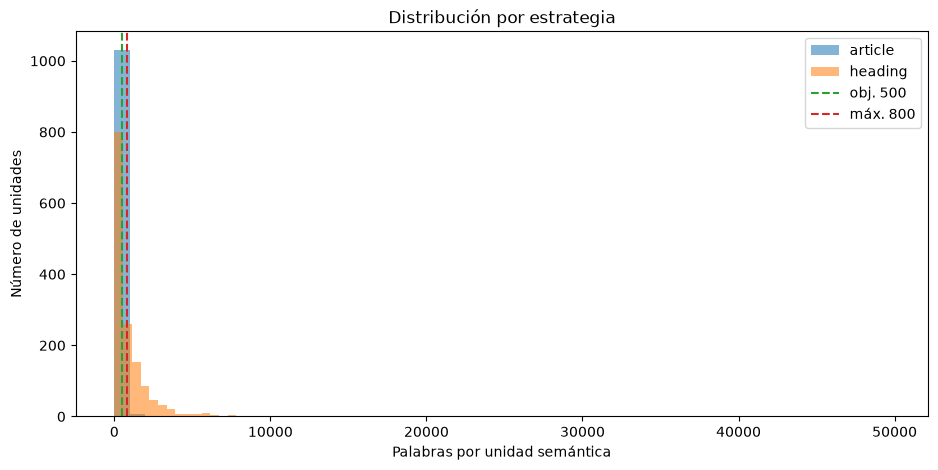

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
for strategy, group in units.groupby('strategy'):
    ax.hist(group.words, bins=50, alpha=.55, label=strategy)
ax.axvline(TARGET_WORDS, color='tab:green', linestyle='--', label=f'obj. {TARGET_WORDS}')
ax.axvline(MAX_WORDS, color='tab:red', linestyle='--', label=f'máx. {MAX_WORDS}')
ax.set(xlabel='Palabras por unidad semántica', ylabel='Número de unidades', title='Distribución por estrategia')
ax.legend()
plt.show()

In [12]:
oversized = units.query('words > @MAX_WORDS').sort_values('words', ascending=False)
undersized = units.query('words < @MIN_WORDS').sort_values(['document', 'position'])
print(f'Unidades > {MAX_WORDS} palabras: {len(oversized)}')
display(oversized[['document', 'strategy', 'title', 'words', 'hierarchy']].head(30))
print(f'Unidades < {MIN_WORDS} palabras: {len(undersized)}')
display(undersized[['document', 'strategy', 'title', 'words', 'hierarchy']].head(30))

Unidades > 800 palabras: 522


,document,strategy,title,words,hierarchy
1065,Código Penal Federal.md,article,Artículo 1,49664,
2334,"Presunción de inocencia, derecho humano en el ...",heading,Apéndice de jurisprudencia,27951,Apéndice de jurisprudencia
1429,El amparo y su relación con el sistema penal a...,heading,ACTOS RECLAMABLES EN LA INVESTIGACIÓN PRELIMIN...,11031,ACTOS RECLAMABLES EN LA INVESTIGACIÓN PRELIMIN...
5,Aplicación del CNPP.md,heading,LA NECESIDAD DE UN PROCEDIMIENTO PENAL ÚNICO P...,10465,LA NECESIDAD DE UN PROCEDIMIENTO PENAL ÚNICO P...
2071,La víctima en el nuevo proceso penal acusatori...,heading,"II. derecho, estado y modernidad",9676,"JOSé zAMORA GRANT > II. derecho, estado y mode..."
2213,Los principios en el procedimiento penal acusa...,heading,Y añade que,8961,LOS PRINCIPIOS EN EL PROCEDIMIENTO PENAL ACUSA...
2197,Los principios en el procedimiento penal acusa...,heading,2. Lo que hace el derecho (en general),7695,LOS PRINCIPIOS EN EL PROCEDIMIENTO PENAL ACUSA...
1772,La casación y el derecho a recurrir.md,heading,III. análisis dE los Motivos dE nulidad,7619,III. análisis dE los Motivos dE nulidad
2124,Los jueces de control en el sistema acusatorio...,heading,5. Técnicas de investigación,7354,SALVADOR CASTILLO GARRIDO > 5. Técnicas de inv...
2047,La prueba libre y lógica. Sistema penal acusat...,heading,c. Los conocimientos científicamente afianzados,7030,LA VALORACIÓN LIBRE Y LÓGICA DE LA PRUEBA Y SU...


Unidades < 80 palabras: 718


,document,strategy,title,words,hierarchy
0,Aplicación del CNPP.md,heading,INSTITUTO DE FORMACIÓN PROFESIONAL DE LA PROCU...,35,INSTITUTO DE FORMACIÓN PROFESIONAL DE LA PROCU...
3,Aplicación del CNPP.md,heading,presentación,62,PRESENTACIÓN > presentación
4,Aplicación del CNPP.md,heading,Capítulo primero,3,Capítulo primero
24,Código Nacional de Procedimientos Penales.md,article,Artículo 1o,68,
27,Código Nacional de Procedimientos Penales.md,article,Artículo 4o,79,
29,Código Nacional de Procedimientos Penales.md,article,Artículo 6o,35,
30,Código Nacional de Procedimientos Penales.md,article,Artículo 7o,26,
31,Código Nacional de Procedimientos Penales.md,article,Artículo 8o,54,
32,Código Nacional de Procedimientos Penales.md,article,Artículo 9o,74,
34,Código Nacional de Procedimientos Penales.md,article,Artículo 11,39,


## 5. Regla de chunking recomendada

1. **Ley/código (`article`)**: conservar un artículo por chunk cuando mida hasta 800 palabras; sobre ese límite, dividir por párrafos con solapamiento de 80 palabras.
2. **Doctrina/jurisprudencia (`heading`)**: usar el bloque de encabezado como unidad; fusionar bloques hermanos de menos de 80 palabras y dividir los mayores a 800 por párrafos.
3. En todo chunk almacenar `source`, `title`, `hierarchy`, `unit_type` y `position`. La jerarquía se inyecta como prefijo sólo al texto que se embebe.

Se implementa en dos pasos deterministas para poder inspeccionarlos antes de conectarlos al índice: **5.1** fusiona los bloques pequeños y **5.2** arma los chunks (partiendo los grandes por párrafos).

### 5.1 Fusión de bloques pequeños (paso previo al chunking)

Implementa el punto 2 de la regla: las unidades de doctrina/jurisprudencia por debajo de `MIN_WORDS` se fusionan con el bloque siguiente del mismo documento antes de armar los chunks. Los artículos de ley se dejan intactos (un artículo es la unidad aunque sea corto). El resultado se inspecciona aquí y alimenta a `make_chunks`.

In [13]:
# Fusión vía shared.legal_chunking.merge_small_siblings.
merged_units = merge_small_siblings(units)
assert int(merged_units.words.sum()) == int(units.words.sum()), 'la fusión alteró el texto'
still_small = merged_units.query("unit_type != 'article' and words < @MIN_WORDS")
merge_summary = pd.Series({
    'unidades_semanticas': len(units),
    'tras_fusion': len(merged_units),
    'reduccion_%': round(100 * (1 - len(merged_units) / len(units)), 1),
    'bloques_fusionados': int((merged_units.merged_units > 1).sum()),
    'restantes_<min': len(still_small),
})
print(merge_summary.to_string())
merged_units.query('merged_units > 1')[['document', 'title', 'merged_units', 'merged_titles', 'words']].head(10)

unidades_semanticas    2483.0
tras_fusion            2235.0
reduccion_%              10.0
bloques_fusionados      194.0
restantes_<min            0.0


,document,title,merged_units,merged_titles,words
0,Aplicación del CNPP.md,Capítulo segundo,2,INSTITUTO DE FORMACIÓN PROFESIONAL DE LA PROCU...,376
2,Aplicación del CNPP.md,LA NECESIDAD DE UN PROCEDIMIENTO PENAL ÚNICO P...,3,presentación + Capítulo primero + LA NECESIDAD...,10530
1063,Dato de prueba en el sistema penal acusatorio.md,DATO DE PRUEBA EN EL PROCESO ACUSATORIO Y ORAL,2,DATO DE PRUEBA + DATO DE PRUEBA EN EL PROCESO ...,998
1069,Dato de prueba en el sistema penal acusatorio.md,A. Lugar como sitio físico,2,1. El lugar como escena del crimen + A. Lugar ...,1216
1081,Dato de prueba en el sistema penal acusatorio.md,y aSeguraMiento de eVidencia FíSica,2,III. detención policial + y aSeguraMiento de e...,2536
1087,Dato de prueba en el sistema penal acusatorio.md,1. Principio de igualdad procesal y acceso a l...,2,IV. deSahogo de prueba y datoS de prueba en au...,466
1094,Desafíos en el Sistema Penal Acusatorio.md,INTRODUCCIÓN,2,PRESENTACIÓN + INTRODUCCIÓN,409
1105,Desafíos en el Sistema Penal Acusatorio.md,1. Publicaciones,2,IX. fuenteS De conSulta + 1. Publicaciones,258
1124,Desafíos en el Sistema Penal Acusatorio.md,con arma De fueGo,2,II. la inveStiGación De loS DelitoS + con arma...,575
1128,Desafíos en el Sistema Penal Acusatorio.md,V. la iDentificación De loS ProyectileS,2,NATARÉN NANDAYAPA / RAMÍREZ SAAVEDRA + V. la i...,239


In [14]:
# Armado de chunks vía shared.legal_chunking (split_by_paragraphs + make_chunks).
chunks = make_chunks(merged_units)
chunks[['source', 'unit_type', 'title', 'part', 'words']].head()

,source,unit_type,title,part,words
0,Aplicación del CNPP.md,heading,Capítulo segundo,1,376
1,Aplicación del CNPP.md,heading,PRESENTACIÓN,1,234
2,Aplicación del CNPP.md,heading,LA NECESIDAD DE UN PROCEDIMIENTO PENAL ÚNICO P...,1,796
3,Aplicación del CNPP.md,heading,LA NECESIDAD DE UN PROCEDIMIENTO PENAL ÚNICO P...,2,772
4,Aplicación del CNPP.md,heading,LA NECESIDAD DE UN PROCEDIMIENTO PENAL ÚNICO P...,3,785


In [15]:
report = pd.Series({
    'documents': len(inventory),
    'semantic_units': len(units),
    'merged_units': len(merged_units),
    'final_chunks': len(chunks),
    'median_chunk_words': chunks.words.median(),
    'p90_chunk_words': chunks.words.quantile(.90),
    'chunks_at_or_below_max': (chunks.words <= MAX_WORDS).mean(),
    'min_chunk_words': int(chunks.words.min()),
})
report

documents                   24.0
semantic_units            2483.0
merged_units              2235.0
final_chunks              3616.0
median_chunk_words         475.0
p90_chunk_words            786.0
chunks_at_or_below_max       1.0
min_chunk_words              8.0
dtype: float64

## 6. Evidencia de detección y limpieza

Estas comprobaciones son pruebas del pipeline: comparan cada coincidencia detectada en el texto limpio con las unidades generadas y verifican que las señales de la ficha catalográfica ya no estén presentes.

In [16]:
def matched_lines(text: str, pattern: re.Pattern, kind: str) -> pd.DataFrame:
    rows = []
    for line_number, line in enumerate(text.splitlines(), start=1):
        match = pattern.match(line)
        if match:
            # El nivel sólo aplica a encabezados; un artículo suele ser negrita en
            # línea (sin '#'), así que se reporta el nivel de '#' si existe, o 0.
            hashes = re.match(r'^[ \t]*(#+)', line)
            level = len(match.group(1)) if kind == 'heading' else (len(hashes.group(1)) if hashes else 0)
            rows.append({'type': kind, 'line': line_number, 'level': level, 'matched_text': normalize_line(line)})
    return pd.DataFrame(rows)

law_document = inventory.query("strategy == 'article'").iloc[0].document
heading_document = 'Técnicas, actos y actuaciones de investigación criminal.md'
heading_matches = matched_lines(documents[heading_document], HEADING_RE, 'heading')
article_matches = matched_lines(documents[law_document], ARTICLE_RE, 'article')

print(f'Encabezados detectados en {heading_document}: {len(heading_matches)}')
display(heading_matches.head(12))
print(f'Artículos detectados en {law_document}: {len(article_matches)}')
display(article_matches.head(12))

Encabezados detectados en Técnicas, actos y actuaciones de investigación criminal.md: 38


,type,line,level,matched_text
0,heading,106,2,## Presentación
1,heading,161,1,# primera parte
2,heading,441,1,# 1. Legalidad
3,heading,459,1,# 2. Objetividad
4,heading,501,1,# 3. Eficiencia
5,heading,517,1,# 4. Profesionalismo
6,heading,535,1,# 5. Honradez
7,heading,551,1,# 6. Lealtad
8,heading,557,1,# 7. Respeto a los derechos humanos reconocido...
9,heading,601,2,## Germán Guillén López


Artículos detectados en Código Penal Federal.md: 551


,type,line,level,matched_text
0,article,25,0,Artículo 1o .- Este Código se aplicará en toda...
1,article,29,0,"Artículo 2o .- Se aplicará, asimismo:"
2,article,35,0,Artículo 3o .- Los delitos continuos cometidos...
3,article,43,0,Artículo 4o .- Los delitos cometidos en territ...
4,article,51,0,Artículo 5o .- Se considerarán como ejecutados...
5,article,63,0,Artículo 6o .- Cuando se cometa un delito no p...
6,article,75,0,Artículo 7o .- Delito es el acto u omisión que...
7,article,97,0,Artículo 8o .- Las acciones u omisiones delict...
8,article,101,0,"Artículo 9o .- Obra dolosamente el que, conoci..."
9,article,109,0,Artículo 10 .- La responsabilidad penal no pas...


In [17]:
# Cada match debe generar exactamente una unidad semántica antes de partir los bloques grandes.
detected = inventory.set_index('document')[['headings', 'articles', 'strategy']]
generated = units.groupby('document').size().rename('semantic_units')
structure_validation = detected.join(generated)
structure_validation['expected_units'] = np.where(structure_validation.strategy.eq('article'), structure_validation.articles, structure_validation.headings)
structure_validation['matches_units'] = structure_validation.semantic_units.eq(structure_validation.expected_units)
assert structure_validation.matches_units.all()
structure_validation[['strategy', 'headings', 'articles', 'semantic_units', 'matches_units']]

,strategy,headings,articles,semantic_units,matches_units
document,,,,,
Código Penal Federal.md,article,380,551,551,True
DialogoRegional SCJN.md,heading,173,1,173,True
Desafíos en el Sistema Penal Acusatorio.md,heading,145,12,145,True
Enseñanza judicial para la valoración de la prueba.md,heading,181,3,181,True
"Los jueces de control en el sistema acusatorio en México, segunda edición.md",heading,87,31,87,True
Los principios en el procedimiento penal acusatorio.md,heading,51,0,51,True
"Presunción de inocencia, derecho humano en el sistema penal acusatorio. Apéndice de Jurisprudencia relacionada.md",heading,49,4,49,True
La prueba libre y lógica. Sistema penal acusatorio mexicano.md,heading,65,28,65,True
Código Nacional de Procedimientos Penales.md,article,631,491,491,True


### Guardas de regresión (clasificación y limpieza)

Estas comprobaciones contrastan la estrategia elegida con señales independientes y fallan si reaparece alguna de las dos fallas detectadas: (1) un documento con muchos artículos que no se enruta a `article` porque el detector no reconoció su formato, o (2) mobiliario de página (folios o títulos-corredor con forma de encabezado) que sobrevive a la limpieza. Ejecútalas al cambiar el corpus o cualquier regla.

In [18]:
# ── Guardas contra clasificación y limpieza incorrectas ─────────────────────────
# Detectan las dos fallas ya corregidas y cualquier reaparición al cambiar el corpus
# o las reglas. Idea: no confiar en que la estrategia elegida sea la correcta, sino
# contrastarla con señales independientes y afirmar que nada quedó mal enrutado en
# NINGUNA dirección.

def repeated_heading_titles(text: str, min_repeats: int = 6) -> dict:
    """Encabezados cuyo texto se repite >= min_repeats: casi siempre título-corredor."""
    heads = Counter(normalize_line(l) for l in text.splitlines() if l.lstrip().startswith('#'))
    return {h: n for h, n in heads.items() if h and n >= min_repeats}

diagnostics = pd.DataFrame([
    {
        'document': name,
        'strategy': document_strategy(text),
        'articles': len(ARTICLE_RE.findall(text)),
        'art_density': round(article_density(text), 2),
        'headings': len(HEADING_RE.findall(text)),
        # Mobiliario que debió eliminarse en la limpieza (bug 2).
        'numeric_headings': sum(bool(HEADING_PAGE_RE.match(l.strip())) for l in text.splitlines()),
        'repeated_headings': len(repeated_heading_titles(text)),
    }
    for name, text in documents.items()
])
looks_like_code = (diagnostics.articles >= 10) & (diagnostics.art_density >= ARTICLE_DENSITY_MIN)
# (a) un código que NO se enrutó a 'article' → el detector de artículos se quedó corto (bug 1).
diagnostics['code_not_routed'] = looks_like_code & (diagnostics.strategy != 'article')
# (b) prosa enrutada a 'article' pese a densidad baja → sobre-corrección del umbral.
diagnostics['prose_routed_as_code'] = (diagnostics.strategy == 'article') & (diagnostics.art_density < ARTICLE_DENSITY_MIN)
# (c) mobiliario de página con forma de encabezado que sobrevive a la limpieza (bug 2).
diagnostics['residual_furniture'] = (diagnostics.numeric_headings > 0) | (diagnostics.repeated_headings > 0)

flagged = diagnostics.query('code_not_routed or prose_routed_as_code or residual_furniture')
if len(flagged):
    display(flagged)
assert not diagnostics.code_not_routed.any(), (
    'Un código (>=10 artículos densos) no se enrutó a la estrategia article: '
    f'{diagnostics.loc[diagnostics.code_not_routed, "document"].tolist()}'
)
assert not diagnostics.prose_routed_as_code.any(), (
    'Prosa con densidad de artículos baja se enrutó como código (umbral demasiado laxo): '
    f'{diagnostics.loc[diagnostics.prose_routed_as_code, "document"].tolist()}'
)
assert not diagnostics.residual_furniture.any(), (
    'Sobrevive mobiliario de página (encabezados numéricos o repetidos) tras la limpieza: '
    f'{diagnostics.loc[diagnostics.residual_furniture, "document"].tolist()}'
)
print('✓ Clasificación consistente en ambas direcciones y sin mobiliario de página residual.')
diagnostics[['strategy', 'articles', 'art_density', 'headings', 'numeric_headings', 'repeated_headings']]

✓ Clasificación consistente en ambas direcciones y sin mobiliario de página residual.


,strategy,articles,art_density,headings,numeric_headings,repeated_headings
0,heading,4,0.12,24,0,0
1,article,491,6.17,631,0,0
2,article,551,4.29,380,0,0
3,heading,1,0.02,33,0,0
4,heading,12,0.11,145,0,0
5,heading,1,0.01,173,0,0
6,heading,2,0.04,28,0,0
7,heading,1,0.03,48,0,0
8,heading,3,0.03,181,0,0
9,heading,10,0.20,82,0,0


In [19]:
# Se eliminan fichas catalográficas/editoriales. Las secciones académicas de ‘Bibliografía’ se conservan.
CATALOG_FIELD_RE = re.compile(r'(?im)^(?:nombres|identificadores|clasificaci[oó]n):')
raw_documents = {path.name: path.read_text(encoding='utf-8') for path in paths}

def has_catalog_signal(text: str) -> bool:
    normalized = '\n'.join(normalize_line(line) for line in text.splitlines())
    return bool(CATALOG_RECORD_RE.search(normalized) or CATALOG_FIELD_RE.search(normalized))

catalog_validation = pd.DataFrame([
    {'document': name, 'catalog_in_raw': has_catalog_signal(raw_documents[name]),
     'catalog_after_cleaning': has_catalog_signal(documents[name]),
     'catalog_lines_removed': cleaned[name]['removed_by_reason'].get('catalog_record', 0)}
    for name in documents
])
assert not catalog_validation.catalog_after_cleaning.any()
catalog_validation.query('catalog_in_raw').sort_values('catalog_lines_removed', ascending=False)

,document,catalog_in_raw,catalog_after_cleaning,catalog_lines_removed
23,"Técnicas, actos y actuaciones de investigación...",True,False,15
9,Juicios Orales y Derechos Humanos.md,True,False,13


## 7. Presupuesto de tokens e inspección

Un chunk se embebe como **un** vector y el modelo sólo lee hasta su `ctx`; lo que sobra se trunca en silencio. Aquí se cuenta el número **real** de tokens de cada chunk con el tokenizer del modelo servido por TEI (no una estimación por palabras) y se verifica que ninguno rebase el `ctx`. Luego se muestran chunks de muestra por estrategia para leerlos a ojo. Requiere el túnel al TEI arriba (`./tunnel.sh`).

In [20]:
import os, json, time, urllib.request
from http.client import IncompleteRead
from concurrent.futures import ThreadPoolExecutor

TEI_URL = os.environ.get('TEI_URL', 'http://localhost:8085')

def _tei_post(path, payload, timeout=120, retries=4):
    """POST resiliente: el túnel a veces corta la respuesta (IncompleteRead) o
    da timeout; reintenta con backoff en vez de tumbar todo el notebook."""
    data = json.dumps(payload).encode()
    for attempt in range(retries):
        try:
            req = urllib.request.Request(TEI_URL + path, data=data,
                                         headers={'Content-Type': 'application/json'})
            return json.load(urllib.request.urlopen(req, timeout=timeout))
        except (IncompleteRead, urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == retries - 1:
                raise
            time.sleep(1.5 * (attempt + 1))

def _batched(items, batch):
    items = list(items)
    return [items[i:i + batch] for i in range(0, len(items), batch)]

def _tei_map(path, batches, workers, build):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(lambda b: _tei_post(path, build(b)), batches))

# /tokenize devuelve los IDs completos (respuesta pesada) → lotes chicos y poca
# concurrencia; sólo nos interesa el CONTEO por texto.
def tei_token_counts(texts, batch=8, workers=4):
    results = _tei_map('/tokenize', _batched(texts, batch), workers, lambda b: {'inputs': b})
    return [len(t) for b in results for t in b]

info = json.load(urllib.request.urlopen(TEI_URL + '/info', timeout=10))
EMBED_MODEL = info['model_id']
EMBED_CTX = int(info.get('max_input_length') or 0)
print(f'Embedder servido por TEI: {EMBED_MODEL}  |  ctx = {EMBED_CTX} tokens')

# Presupuesto de tokens SIN saturar el túnel: tokenizar los 3616 chunks lo tira. Basta
# con (a) una muestra aleatoria para el ratio tokens/palabra y el tamaño típico, y
# (b) los chunks MÁS GRANDES por palabras —los únicos que podrían acercarse al ctx—,
# que se tokenizan exactos para el chequeo de truncamiento.
rng = np.random.default_rng(0)
sample = chunks.iloc[rng.choice(len(chunks), size=min(400, len(chunks)), replace=False)]
largest = chunks.nlargest(80, 'words')

sample_tokens = np.array(tei_token_counts(sample['text_for_embedding'].tolist()))
largest_tokens = np.array(tei_token_counts(largest['text_for_embedding'].tolist()))
ratio = sample_tokens.sum() / max(sample['words'].sum(), 1)

token_report = pd.Series({
    'muestra_chunks': len(sample),
    'tokens_por_palabra': round(float(ratio), 2),
    'muestra_median_tokens': int(np.median(sample_tokens)),
    'muestra_p95_tokens': int(np.quantile(sample_tokens, .95)),
    'max_tokens_80_mayores': int(largest_tokens.max()),
    'ctx_modelo': EMBED_CTX,
    'chunks_truncados': int((largest_tokens > EMBED_CTX).sum()),
})
print(token_report.to_string())
# El peor caso está entre los más grandes por palabras (más palabras ⇒ más tokens).
assert largest_tokens.max() <= EMBED_CTX, 'El chunk más grande rebasa el ctx y se truncaría'

# Inspección a ojo: 2 chunks por tipo de unidad (se tokenizan sólo esos para mostrar).
inspection = pd.concat([g.sample(min(2, len(g)), random_state=0)
                        for _, g in chunks.groupby('unit_type')])
insp_tokens = tei_token_counts(inspection['text_for_embedding'].tolist())
for r, tok in zip(inspection.itertuples(), insp_tokens):
    print('\n' + '─' * 88)
    print(f'[{r.unit_type}] {r.source} · {r.title} · {r.words} palabras / {tok} tokens')
    print(r.text_for_embedding[:500] + ('…' if len(r.text_for_embedding) > 500 else ''))


Embedder servido por TEI: Qwen/Qwen3-Embedding-0.6B  |  ctx = 16384 tokens


muestra_chunks             400.00
tokens_por_palabra           1.85
muestra_median_tokens      895.00
muestra_p95_tokens        1492.00
max_tokens_80_mayores     2731.00
ctx_modelo               16384.00
chunks_truncados             0.00



────────────────────────────────────────────────────────────────────────────────────────
[article] Código Nacional de Procedimientos Penales.md · Artículo 266 · 108 palabras / 227 tokens
Fuente: Código Nacional de Procedimientos Penales.md
Sección: Artículo 266

## **Artículo 266. Actos de molestia** 

Todo acto de molestia deberá llevarse a cabo con respeto a la dignidad de la persona en cuestión. Antes de que el procedimiento se lleve a cabo, la autoridad deberá informarle sobre los derechos que le asisten y solicitar su cooperación. Se realizará un registro forzoso sólo si la persona no está dispuesta a 

**<u>CÓDIGO NACIONAL DE PROCEDIMIENTOS PENALES</u>** 

_Última Reforma …

────────────────────────────────────────────────────────────────────────────────────────
[article] Código Penal Federal.md · Artículo 166 · 528 palabras / 1089 tokens
Fuente: Código Penal Federal.md
Sección: Artículo 166

**Artículo 166 Bis.-** A las personas que por razón de su cargo o empleo en empresas de

## 8. Evaluación de recuperación (el juez real)

Todo lo anterior valida la *mecánica* (cortes limpios, tamaños, sin ruido). Esto valida lo que importa: **¿el chunking recupera el pasaje correcto ante una pregunta real?** Se compara el chunking por estructura contra un baseline de tamaño fijo sobre el mismo texto, embediendo con el modelo servido por TEI (`Qwen3-Embedding-0.6B`) y midiendo `hit@k` y `MRR` sobre un set semilla de preguntas ancladas a frases verificables.

Requiere el túnel al TEI arriba. El set es una **semilla** para ampliar con preguntas reales; la relevancia es un proxy por contenido (si mejora aquí, confírmalo luego con juicios humanos).

In [21]:
import hashlib
from concurrent.futures import ThreadPoolExecutor

# Embebido paralelo con caché en disco. El túnel embebe ~10 textos/s en serie; en
# paralelo baja a un par de minutos y la caché hace instantáneas las re-corridas.
CACHE_DIR = labs_folder / 'exploracion_datos' / '.embed_cache'
CACHE_DIR.mkdir(exist_ok=True)

def embed_texts(texts, batch=32, workers=8):
    texts = list(texts)
    key = hashlib.md5((EMBED_MODEL + '\n' + '\n'.join(texts)).encode('utf-8')).hexdigest()
    cache = CACHE_DIR / f'{key}.npy'
    if cache.exists():
        return np.load(cache)
    results = _tei_map('/embed', _batched(texts, batch), workers,
                       lambda b: {'inputs': b, 'normalize': True, 'truncate': True})
    arr = np.asarray([v for b in results for v in b], dtype=np.float32)
    np.save(cache, arr)
    return arr

# Baseline honesto: tamaño fijo sobre el MISMO texto limpio (lo que el chunking por
# estructura reemplaza). Si la estructura no le gana a esto, no vale la pena.
def fixed_size_chunks(text, size=TARGET_WORDS, overlap=OVERLAP_WORDS):
    w = text.split(); step = max(1, size - overlap); out = []
    for s in range(0, len(w), step):
        piece = w[s:s + size]
        if piece:
            out.append(' '.join(piece))
        if s + size >= len(w):
            break
    return out

baseline = pd.DataFrame([{'source': name, 'text': c}
                         for name, text in documents.items()
                         for c in fixed_size_chunks(text)])

# Golden set DIFÍCIL: preguntas parafraseadas o de escenario, con mínimo solape léxico
# con la respuesta (la pregunta NO usa las palabras clave del artículo). Fuerza al
# embedder a resolver por semántica, no por coincidencia de términos — así hit@3/hit@5
# dejan de saturarse. `answer` es la frase verificable que el chunk correcto contiene.
golden = pd.DataFrame([
    {'q': '¿Se puede tratar a un acusado como culpable antes de que un juez dicte sentencia?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'se presume inocente y será tratada como tal'},
    {'q': '¿Qué grado de certeza necesita el tribunal para poder condenar a una persona?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'más allá de toda duda razonable'},
    {'q': '¿Cómo se garantiza que la evidencia recogida en la escena no se altere ni se cambie?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'sistema de control y registro que se aplica al indicio'},
    {'q': 'Si la policía obtiene una prueba violando derechos, ¿esa prueba puede usarse en el juicio?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'Cualquier acto realizado con violación de derechos humanos será nulo'},
    {'q': '¿Qué debe ocurrir para que el fiscal logre que el proceso continúe formalmente contra el imputado?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'dictará el auto de vinculación del imputado a proceso'},
    {'q': '¿Puede la víctima llegar a un arreglo con el acusado para resolver el asunto sin llegar a juicio?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'acuerdos reparatorios son aquéllos celebrados entre la víctima u ofendido y el imputado'},
    {'q': '¿Pueden juzgar a alguien otra vez por un delito del que ya fue absuelto?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'no podrá ser sometida a otro proceso penal por los mismos hechos'},
    {'q': '¿La defensa tiene derecho a rebatir y objetar los elementos que presenta la fiscalía?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'controvertir o confrontar los medios de prueba'},
    {'q': '¿En qué condición es legítimo detener y retener físicamente a una persona?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'nadie podrá ser privado de la misma'},
    {'q': '¿Qué diligencias puede llevar a cabo el ministerio público sin pedir permiso a un juez?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'No requieren autorización del Juez de control'},
    {'q': '¿Se le puede imponer al imputado más de una restricción al mismo tiempo durante el proceso?',
     'source': 'Código Nacional de Procedimientos Penales.md',
     'answer': 'una o varias de las siguientes medidas cautelares'},
    {'q': '¿Qué significa que un elemento constituya un indicio con valor probatorio en la etapa inicial?',
     'source': 'Dato de prueba en el sistema penal acusatorio.md',
     'answer': 'dato de prueba es la referencia al contenido de un determinado medio'},
])
# El eval está bien planteado sólo si la frase-respuesta existe en el corpus limpio.
for it in golden.itertuples():
    assert it.answer in documents[it.source], f'Ancla inexistente tras limpieza: {it.answer!r}'

# Qwen3-Embedding rinde mejor con una instrucción en la consulta (no en los documentos).
Q_INSTRUCT = 'Instruct: Recupera el pasaje del código o la doctrina que responde la pregunta.\nQuery: '
qvecs = embed_texts([Q_INSTRUCT + q for q in golden.q])

def evaluate(chunk_texts, ks=(1, 3, 5)):
    chunk_texts = list(chunk_texts)
    vecs = embed_texts(chunk_texts)                       # normalizados → coseno = producto punto
    hits = {f'hit@{k}': [] for k in ks}
    reciprocal_ranks = []
    for qi, it in enumerate(golden.itertuples()):
        order = np.argsort(-(vecs @ qvecs[qi]))
        relevant = [it.answer in chunk_texts[j] for j in order]
        first = next((rank for rank, r in enumerate(relevant, start=1) if r), None)
        reciprocal_ranks.append(1.0 / first if first else 0.0)
        for k in ks:
            hits[f'hit@{k}'].append(bool(any(relevant[:k])))
    return pd.Series({**{m: float(np.mean(v)) for m, v in hits.items()},
                      'MRR': float(np.mean(reciprocal_ranks))})

comparison = pd.DataFrame({
    'estructura (art/heading + merge)': evaluate(chunks['text_for_embedding']),
    'tamaño fijo (baseline)': evaluate(baseline['text']),
}).round(3)
print(f'Preguntas (difíciles): {len(golden)} · chunks estructura: {len(chunks)} · chunks baseline: {len(baseline)}')
comparison


Preguntas (difíciles): 12 · chunks estructura: 3616 · chunks baseline: 3650


,estructura (art/heading + merge),tamaño fijo (baseline)
hit@1,0.083,0.083
hit@3,0.083,0.083
hit@5,0.167,0.083
MRR,0.122,0.100


In [22]:
# Diagnóstico por pregunta: ¿en qué rank aparece el chunk correcto y qué se trajo en
# su lugar? Sirve para distinguir si falla el chunking, el embedder o el proxy de
# relevancia (frase-en-chunk). Usa embeddings ya cacheados → instantáneo.
struct_vecs = embed_texts(chunks['text_for_embedding'].tolist())
base_vecs = embed_texts(baseline['text'].tolist())
struct_texts = chunks['text_for_embedding'].tolist()
base_texts = baseline['text'].tolist()

def first_rank(vecs, texts, answer, qvec):
    order = np.argsort(-(vecs @ qvec))
    for rank, j in enumerate(order, start=1):
        if answer in texts[j]:
            return rank, order
    return None, order

diag_rows = []
for qi, it in enumerate(golden.itertuples()):
    r_s, order_s = first_rank(struct_vecs, struct_texts, it.answer, qvecs[qi])
    r_b, _ = first_rank(base_vecs, base_texts, it.answer, qvecs[qi])
    top = chunks.iloc[order_s[0]]
    diag_rows.append({
        'pregunta': it.q[:58],
        'rank_estruct': r_s if r_s else '∞',
        'rank_base': r_b if r_b else '∞',
        'top1_estruct_trajo': f'{top.source[:22]} · {str(top.title)[:32]}',
    })

diagnostico = pd.DataFrame(diag_rows)
with pd.option_context('display.max_colwidth', 70, 'display.width', 200):
    display(diagnostico)

fallan_top5 = diagnostico[diagnostico.rank_estruct.apply(lambda r: r == '∞' or r > 5)]
print(f'\nPreguntas donde la estructura NO recupera en top-5: {len(fallan_top5)}/{len(golden)}')


,pregunta,rank_estruct,rank_base,top1_estruct_trajo
0,¿Se puede tratar a un acusado como culpable antes de que u,10,290,Los principios en el p · 2. Lo que hace el derecho (en ge
1,¿Qué grado de certeza necesita el tribunal para poder cond,1,1,La prueba libre y lógi · J. Estándar probatorio requerido
2,¿Cómo se garantiza que la evidencia recogida en la escena,27,9,La policía de investig · acta de preservación y conservac
3,"Si la policía obtiene una prueba violando derechos, ¿esa p",1194,2025,Código Nacional de Pro · Artículo 357
4,¿Qué debe ocurrir para que el fiscal logre que el proceso,37,157,El amparo y su relació · LOS ACTOS RECLAMABLES EN LA INVE
5,¿Puede la víctima llegar a un arreglo con el acusado para,310,180,La víctima en el nuevo · a. La negociación del conflicto
6,¿Pueden juzgar a alguien otra vez por un delito del que ya,5,379,Código Penal Federal.m · Artículo 118
7,¿La defensa tiene derecho a rebatir y objetar los elemento,43,237,La formulación de impu · iii aCCeSo Del imputaDo a loS re
8,¿En qué condición es legítimo detener y retener físicament,127,931,DialogoRegional SCJN.m · Estándares aplicables desde el m
9,¿Qué diligencias puede llevar a cabo el ministerio público,27,429,Código Nacional de Pro · Artículo 24



Preguntas donde la estructura NO recupera en top-5: 10/12


## Siguiente paso

Con la mecánica validada (§1–7) y el eval de recuperación en marcha (§8), lo que sigue es:

1. **Ampliar el golden set** con preguntas reales de usuarios (no sólo artículos del CNPP) y, si es posible, con juicios humanos de relevancia en vez del proxy por contenido.
2. **Decidir con el eval, no con la distribución de tamaños**: ajusta `TARGET_WORDS`, `MAX_WORDS`, `MIN_WORDS` y la lista de ruido según `hit@k`/`MRR`.
3. **Portar la lógica al pipeline de ingestión** (`document_strategy`, limpieza y merge) una vez que el eval confirme que la estructura le gana al baseline de tamaño fijo.